In [1]:
import pandas as pd
import numpy as np

import torch

from Bio import SeqIO
from tqdm import tqdm
import os

In [2]:
import h5py

In [3]:
h5_path = "/project2/fudenber_735/smaruj/akitaX1_analyses_data/virtual_insertion_singletons/model_0.h5"

In [4]:
with h5py.File(h5_path, "r") as f:
    scd = f["SCD_h1_m0"][:]            # (75600, 6)
    background_index = f["background_index"][:]  # (75600,)
    seq_id = f["seq_id"][:]            # (75600,)

    # Decode byte strings to normal strings
    chrom = [c.decode("utf-8") for c in f["chrom"][:]]
    strand = [s.decode("utf-8") for s in f["strand"][:]]

    end = f["end"][:]
    start = f["start"][:]

# Take 0th target
scd_target0 = scd[:, 0]  # shape (75600,)

# Average over backgrounds
# Assuming background_index goes from 0..9 for the 10 backgrounds
df = pd.DataFrame({
    "seq_id": seq_id,
    "background_index": background_index,
    "SCD": scd_target0,
    "chrom": chrom,
    "end": end,
    "start": start,
    "strand": strand
})

# Average SCD per location over backgrounds
df_avg = (
    df.groupby(["chrom", "start", "end", "strand"], as_index=False)["SCD"]
      .mean()
)

In [5]:
df_top5_ctcf = df_avg.sort_values("SCD", ascending=False).head(5)

In [6]:
df_top5_ctcf

,chrom,start,end,strand,SCD
6222,chr7,37357852,37357871,-,65.403122
2353,chr14,87452272,87452291,-,63.087502
2095,chr13,110382723,110382742,+,62.487499
4995,chr4,87368249,87368268,+,62.243752
4385,chr2,172216028,172216047,-,58.756248


In [7]:
mm10_path = "/project2/fudenber_735/genomes/mm10/mm10.fa"

In [8]:
from pyfaidx import Fasta

genome = Fasta(mm10_path)

In [9]:
# Extract ±15 bp around each CTCF site
sequences = []
for _, row in df_top5_ctcf.iterrows():
    chrom = row["chrom"]
    start = int(row["start"]) - 15
    end = int(row["end"]) + 15
    strand = row["strand"]

    # Get sequence
    seq = genome[chrom][start:end].seq.upper()

    # Reverse complement if on minus strand
    if strand == "-":
        from Bio.Seq import Seq
        seq = str(Seq(seq).reverse_complement())

    sequences.append(seq)

In [10]:
df_top5_ctcf["sequence_±15bp"] = sequences

In [11]:
df_top5_ctcf = df_top5_ctcf.reset_index()

In [12]:
df_top5_ctcf

,index,chrom,start,end,strand,SCD,sequence_±15bp
0,6222,chr7,37357852,37357871,-,65.403122,CTGCGATTCCGAATATGGCCACAAGAGGGCACTCGATGTCCACAGAAAG
1,2353,chr14,87452272,87452291,-,63.087502,CTGCACTACCGGAAAAGACCACAAGATGGCAGCATCGATTCACTAGTAA
2,2095,chr13,110382723,110382742,+,62.487499,TGTCATTTTCAACATTGACCAGCAGAGGGCAGTCGAAGTCCAGTCAATA
3,4995,chr4,87368249,87368268,+,62.243752,TGTAGTAGCAACCTATGGCCACTAGATGGCGGGAGAGGACCGAGATAGC
4,4385,chr2,172216028,172216047,-,58.756248,AGCTATCCTCTACAATGTCCACTAGGTGGCACTGTTGCCCTGCTCAGAG


In [13]:
# x_path = "/scratch1/smaruj/generate_genomic_boundary/ohe_X/fold0/chr11_65677312_66988032_X.pt"
x_path = "/scratch1/smaruj/generate_genomic_boundary/ohe_X/fold0/chr1_37799936_39110656_X.pt"

In [14]:
x_orig = torch.load(x_path)

/tmp/SLURM_1852584/ipykernel_3018473/1428884619.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x_orig = torch.load(x_path)


In [15]:
seq_len = x_orig.shape[2]   # should be around 1.3M bp (640 * 2048)
print(seq_len)  # sanity check

1310720


In [16]:
bin_size = 2048
target_bin = 320
bin_start = target_bin * bin_size
bin_center = bin_start + bin_size // 2

spacing = 500  # bp

# Forward motifs >
fwd_positions = [
    bin_center - int(1.5 * spacing),
    bin_center - int(0.5 * spacing),
    bin_center + int(0.5 * spacing),
    bin_center + int(1.5 * spacing)
]
print("Forward positions:", fwd_positions)

Forward positions: [655634, 656134, 656634, 657134]


In [17]:
rev_positions = [
    (fwd_positions[0] + fwd_positions[1]) // 2,
    (fwd_positions[1] + fwd_positions[2]) // 2,
    (fwd_positions[2] + fwd_positions[3]) // 2
]
print("Reverse positions:", rev_positions)

Reverse positions: [655884, 656384, 656884]


In [18]:
def one_hot_encode(seq):
    """
    Input: seq (str)
    Output: torch tensor of shape (4, len(seq)) with one-hot encoding
    A->row0, C->row1, G->row2, T->row3
    """
    mapping = {"A": 0, "C": 1, "G": 2, "T": 3}
    ohe = torch.zeros(4, len(seq), dtype=torch.float32)
    for i, base in enumerate(seq.upper()):
        if base in mapping:
            ohe[mapping[base], i] = 1.0
    return ohe

In [19]:
ctcf_seq = df_top5_ctcf["sequence_±15bp"][0]

In [20]:
ctcf_ohe = one_hot_encode(ctcf_seq)

In [21]:
ctcf_ohe.shape

torch.Size([4, 49])

In [22]:
x_inserted_forward = x_orig.clone()

motif_len = ctcf_ohe.shape[1]

for pos in fwd_positions:
    start = pos - motif_len // 2
    end = start + motif_len

    if start < 0 or end > seq_len:
        raise ValueError("Motif insertion goes out of bounds")

    # Zero out that region first (so it’s replaced cleanly)
    x_inserted_forward[:, :, start:end] = 0.0
    # Insert motif
    x_inserted_forward[:, :, start:end] = ctcf_ohe

In [23]:
def reverse_complement_ohe(ohe):
    """
    Input: ohe tensor of shape (4, L)
    Output: reverse complement tensor (4, L)
    Channel mapping:
        A(0) <-> T(3)
        C(1) <-> G(2)
    """
    # Create a copy
    ohe_rc = ohe.clone()
    
    # Swap channels
    ohe_rc = ohe_rc[[3, 2, 1, 0], :]  # A<->T, C<->G
    
    # Reverse along the sequence axis
    ohe_rc = torch.flip(ohe_rc, dims=[1])
    
    return ohe_rc

In [24]:
ctcf_ohe_rev = reverse_complement_ohe(ctcf_ohe)

In [25]:
x_inserted_forward_reverse = x_orig.clone()

# Interleave motifs
all_positions = []
all_motifs = []

for i in range(len(fwd_positions)):
    # Add forward motif
    all_positions.append(fwd_positions[i])
    all_motifs.append(ctcf_ohe)
    
    # Add reverse motif in between, except after the last forward motif
    if i < len(fwd_positions) - 1:
        all_positions.append(rev_positions[i])
        all_motifs.append(ctcf_ohe_rev)

# Insert motifs
for pos, motif in zip(all_positions, all_motifs):
    start = pos - motif_len // 2
    end = start + motif_len
    if start < 0 or end > seq_len:
        raise ValueError("Motif insertion goes out of bounds")
    
    x_inserted_forward_reverse[0, :, start:end] = 0.0
    x_inserted_forward_reverse[0, :, start:end] = motif

In [26]:
import sys
# Add path to your model code
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))
from model_v2_compatible import SeqNN

In [27]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [28]:
model_path = "/scratch1/smaruj/Akita_pytorch_models/finetuned/mouse_models/target_0/models/Akita_v2_mouse_target0_model0_finetuned.pth"

In [29]:
model = SeqNN()
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

/tmp/SLURM_1852584/ipykernel_3018473/3961615253.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [30]:
with torch.no_grad():
    y_orig = model(x_orig)          # predictions for original sequence
    y_insert_f = model(x_inserted_forward)
    y_insert_fr = model(x_inserted_forward_reverse)

In [31]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [32]:
import matplotlib.pyplot as plt

In [33]:
def urq_mean(contact_map):
    """
    Upper Right Quarter mean
    contact_map: 2D tensor (512x512)
    """
    URQ = contact_map[0:256, 256:512]
    return np.nanmean(URQ)

URQ = 0.04341790095134231


<Figure size 800x800 with 0 Axes>

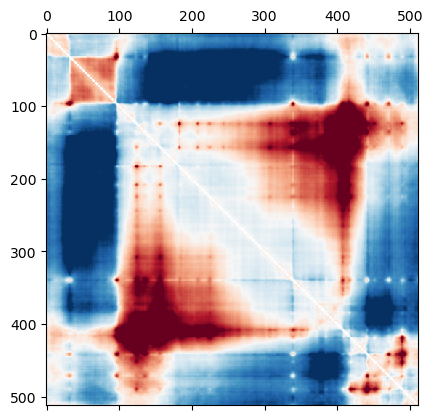

In [34]:
plt.figure(figsize=(8, 8))
matrix = from_upper_triu(y_orig, matrix_len=512, num_diags=2)
print("URQ =", urq_mean(matrix))
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
# plt.colorbar()
plt.show()

URQ = -0.14971013024177632


<Figure size 800x800 with 0 Axes>

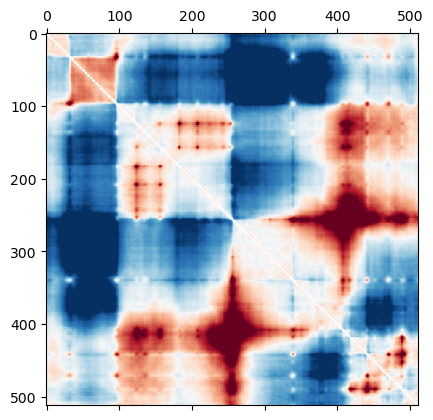

In [35]:
plt.figure(figsize=(8, 8))
matrix = from_upper_triu(y_insert_f, matrix_len=512, num_diags=2)
print("URQ =", urq_mean(matrix))
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
# plt.colorbar()
plt.show()

URQ = -0.1406236423353877


<Figure size 800x800 with 0 Axes>

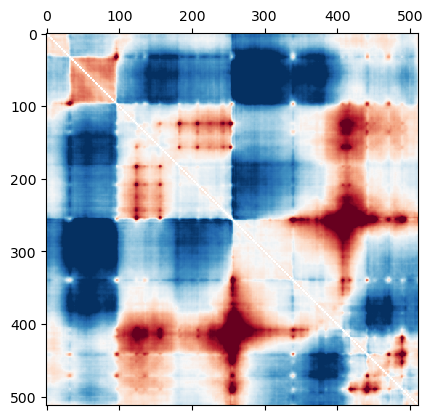

In [36]:
plt.figure(figsize=(8, 8))
matrix = from_upper_triu(y_insert_fr, matrix_len=512, num_diags=2)
print("URQ =", urq_mean(matrix))
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
# plt.colorbar()
plt.show()